### Projet 3 : Synthetisé des données médicales avec la méthode avatar (présenté dans cette [article](https://www.nature.com/articles/s41746-023-00771-5))

**Problématique :** Rocher et al. ont montré que 99,98 % des personnes pouvaient être réidentifiées dans n’importe quel ensemble de données pseudonymisées à l’aide de 15 attributs démographiques. Depuis 2018, la mise en œuvre du Règlement général sur la protection des données (RGPD) en Europe a considérablement modifié le cadre réglementaire de la circulation et de l’utilisation des données personnelles, en favorisant notamment une utilisation plus systématique des techniques d’anonymisation. Pour répondre à ces exigences légales et de confidentialité, les techniques d’anonymisation constituent des solutions pertinentes pour la protection des données. Meme avec une anonymisation il y a toujours un risque de réidentification . 

**La solution :** Remplacer les données réelles par des données synthétiques (méthode Avatar), qui génèrent de nouveaux individus artificiels préservant les propriétés statistiques, tout en éliminant le risque de réidentification des personnes réelles.

**Explications :**
> Chaque avatar est basé sur un patient réel , mais il n'est PAS une copie de ce patient
> Le patient sert de point de départ mais ne contribue pas directement à son avatar . 

- Ex : Pour un patient A :
    - on regarde ses voisins
    - on génère un point autour ( avatar proches des vrais )
MAIS on n’utilise PAS directement A
 
> Le modèle ne génère PAS globalement il travaille dans un petit voisinage local (groupe de patients similaires) , parceque les relations statistiques sont locales
- Ex : patients similaires → mêmes patterns médicaux
- Donc on genere autour du patient 

> Difference avec d'autre modeles GAN/CTGAN :
- apprend une distribution globale
- peut générer n’importe où

> Certains approches disent  "plus les données synthétiques sont loin des vraies → plus c’est sécurisé", donc essaie de  maximiser la distance (synthetic vs real) . Ce qui creer des distribution fausses , corrélation cassé et des modeles ML inutile. La méthodes Avatars dit qu on reste proches des données rééls sans copier mais melanger , donc les donnée :
- restes réalistes 
- mais ne sont pas idéntiques

> Pourquoi faible risque de réidentification ? 
- parcque l’avatar est une combinaison de plusieurs individus
- donc impossible de dire "cet avatar = ce patient"

> Utilité statistiques : le papier dit  même interprétation que les données réelles , c est a dire : 
- distributions proches (reste dans les zones existantes)
- corrélations conservées (mélange des profils similaires)
- modèles ML donnent mêmes résultats ( garde les relations )

AVATAR ne crée rien de nouveau, il recombine intelligemment ce qui existe déjà (combinaison de voisins similaires)

> Pourquoi la projection PCA est au coeur de la méthode : 
- dans les données beaucoup de variables , le calcul de distances deviennent dificille, KNN ne marche pas bien .
- la solution est de projeter les données dans un espace réduit , on garde l essentiel de l information et les distances sont faciles a calculer 
- C est important car les voisins dépendent de la distance
- mauvaise projection = mauvais voisins = mauvais dataset

> L influence de k selon l article : 
- si cas petit : k = 5
    - mélange de 5 patients très proches
    - très réaliste
    - risque de confidentialité 
    - avatar moins diversifié 

- si cas grand : k=50
    - mélange large
    - plus flou
    - securisé 
    - avatar plus diversifié

> k influence confidentialité ET qualité . 

> L auteur propose d adapter k selon la densité :
- zone dense → petit k
- zone rare → grand k

> AVATAR permet de générer autant de données que l on souhaite , chaque génération est différente (processus àleatoires)







### Importation 

In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.stats import wasserstein_distance
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import FunctionTransformer , StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import VarianceThreshold
import itertools
from sklearn.feature_selection import VarianceThreshold

import math


In [2]:
pl.Config.set_tbl_cols(-1) # afficher toute les colonnes 
pl.Config.set_tbl_rows(-1) # afficher toute les lignes

polars.config.Config

In [3]:
data="../../Data/trainDataDC2.csv.gz"
df=pl.read_csv(data)
df.shape

(14575, 21)

In [4]:
df.schema

Schema([('patid', Int64),
        ('index_age', String),
        ('previous_asthma_drugs', String),
        ('total_pre_index_cannisters_365', String),
        ('post_index_exacerbations365', Int64),
        ('pneumonia', String),
        ('sinusitis', String),
        ('acute_bronchitis', String),
        ('acute_laryngitis', String),
        ('upper_respiratory_infection', String),
        ('gerd', String),
        ('rhinitis', String),
        ('adherence', String),
        ('total_pre_index_charge', String),
        ('pre_asthma_days', String),
        ('pre_asthma_charge', String),
        ('pre_asthma_pharma_charge', String),
        ('drug_s', String),
        ('female', String),
        ('log_charges', String),
        ('log_asthma_charge', String)])

### Preprocessing 

In [5]:
df.glimpse()
# affiche :
#le nombre de lignes
# le nombre de colonnes
# le nom et le type de chaque variable
# les valeurs exemples de chaque colonne

Rows: 14575
Columns: 21
$ patid                          <i64> 1073754155, 1073799394, 1073854918, 1073898249, 1073913003, 1073928980, 1074030062, 1074078078, 1074166886, 1074184402
$ index_age                      <str> '14', 'NA', '62', 'NA', '40', '64', '37', '62', '18', 'NA'
$ previous_asthma_drugs          <str> '1', '1', '1', '1', '1', '1', 'NA', '1', '1', '1'
$ total_pre_index_cannisters_365 <str> '1', '2', 'NA', '2', '1', '1', '0', '1', '1', '2'
$ post_index_exacerbations365    <i64> 0, 2, 0, 0, 0, 0, 0, 0, 0, 0
$ pneumonia                      <str> '0', '0', '0', '0', '0', '0', '0', '0', '0', '0'
$ sinusitis                      <str> '0', '1', '0', '0', '1', '0', '0', '0', 'NA', '0'
$ acute_bronchitis               <str> '1', '1', 'NA', '1', '0', '1', '1', '0', '0', '1'
$ acute_laryngitis               <str> '0', '0', '0', '0', '1', '0', '0', '0', '0', '0'
$ upper_respiratory_infection    <str> '1', '0', '0', '1', '1', '1', '0', '1', '0', '0'
$ gerd                          

In [6]:
binary_features = [
    "pneumonia","sinusitis","acute_bronchitis",
    "acute_laryngitis","upper_respiratory_infection",
    "gerd","rhinitis","drug_s","female"
]

numeric_features = [
    "index_age",
    "previous_asthma_drugs",
    "total_pre_index_cannisters_365",
    "pre_asthma_days",
]

skewed_numeric_features = [
    "total_pre_index_charge",
    "pre_asthma_charge",
    "pre_asthma_pharma_charge" ,
    "adherence"
]

In [7]:
def cast_float(df: pl.DataFrame) -> pl.DataFrame:
    return df.with_columns(
        pl.col(skewed_numeric_features)
        .replace("NA", None)
        .cast(pl.Float64, strict=False)
    )


def cast_int(df: pl.DataFrame) -> pl.DataFrame:
    return df.with_columns(
        pl.col(numeric_features)
        .replace("NA", None)
        .cast(pl.Int64, strict=False)
    )


def cast_binary(df: pl.DataFrame) -> pl.DataFrame:
    return df.with_columns(
        pl.col(binary_features)
        .replace("NA", None)
        .cast(pl.Int8, strict=False)
    )

In [8]:
# construct a data transformer from a user-defined function
# input columns → output columns (mêmes noms)
cast_int_transformer = FunctionTransformer(
    cast_int,
    feature_names_out="one-to-one"
)

cast_float_transformer = FunctionTransformer(
    cast_float,
    feature_names_out="one-to-one"
)

cast_binary_transformer = FunctionTransformer(
    cast_binary,
    feature_names_out="one-to-one"
)

log_transformer = FunctionTransformer(
    np.log1p,
    feature_names_out="one-to-one"
)

In [9]:
preprocessor = ColumnTransformer([

    # variables numériques classiques
    ("num_int", Pipeline([
        ("cast", cast_int_transformer),
        ("imputer", SimpleImputer(strategy="median"))
        #("scaler int ", StandardScaler())
    ]), numeric_features),

    # variables skewed (charges)
    ("skewed", Pipeline([
        ("cast", cast_float_transformer),
        ("imputer", SimpleImputer(strategy="median")),
        ("log", log_transformer),
        ("scaler int ", StandardScaler())
    ]), skewed_numeric_features),

    # variables binaires
    ("binary", Pipeline([
        ("cast", cast_binary_transformer),
        ("imputer", SimpleImputer(strategy="most_frequent"))
    ]), binary_features)

])

In [10]:
X= preprocessor.fit_transform(df)
feature_names = preprocessor.get_feature_names_out()

real = pl.DataFrame(X, schema=feature_names.tolist())

### Modele Avatar Article 

Etape : 
1. comprendre la structure globale ("comment les patients sont organisés dans l’espace")
2. regarder localement : Pour chaque patient on regarde ses voisins les plus proches (patients qui lui ressemblent vraiment)
3. créer un nouvel individu : on fait un mélange pondéré de patients similaires (voisins) , elle depend : 
    - proximité : + un voisin est proche + il influence l avatar 
    - controle le hazard pour éviter de toujours générer la même chose
    - hiérarchie : certains voisins comptent plus que d’autres
    - On obtient un nouveau point situé dans la zone réaliste (interpolation)

In [11]:
# --------------------------------------------------
# AVATAR METHOD (faithful implementation)
# --------------------------------------------------
def generate_synthetic(X, k=20, n_components=10, random_state=42):
    """
    X : numpy array (déjà preprocessé)
    k : nombre de voisins
    n_components : dimensions projection
    noise : perturbation optionnelle
    """

    np.random.seed(random_state)

    # -----------------------------
    # 1. PROJECTION (PCA ≈ FAMD simplifié)
    # -----------------------------
    pca = PCA(n_components=n_components)
    X_proj = pca.fit_transform(X)

    n = X_proj.shape[0]

    # -----------------------------
    # 2. KNN (voisinage local)
    # -----------------------------
    knn = NearestNeighbors(n_neighbors=k + 1, metric="euclidean")
    knn.fit(X_proj)

    distances, indices = knn.kneighbors(X_proj)

    # -----------------------------
    # 3. GENERATION AVATAR
    # -----------------------------
    avatars = np.zeros_like(X_proj) # matrice pour stocker les avatars générés (n, n_components)

    for i in range(n):

        # enlever soi-même
        neigh_idx = indices[i][1:] # les indices des k voisins les plus proches (sans soi-même) [v1, v2, v3, ..., vk]
        neigh_dist = distances[i][1:] # les distances aux k voisins les plus proches (sans soi-même) [d1, d2, d3, ..., dk]

        # -----------------------------
        # 3a. Di = inverse distance Di est un vecteur de poids basé sur la proximité des voisins
        # Plus la distance est petite, plus le poids est grand (proche = plus d'influence sur l'avatar)
        # Plus la distance est grande, plus le poids est petit (loin = moins d'influence sur l'avatar)
        # -----------------------------
        Di = 1 / (neigh_dist + 1e-8)  # une pondération inverse de distance
        # inverser les distances pour donner plus de poids aux voisins proches (éviter division par zéro)
        # 1e-8 est ajouté pour éviter la division par zéro si un voisin est exactement à distance zéro (très rare mais possible)

        # -----------------------------
        # 3b. Ri ~ exp(1) (variabilité aléatoire)
        # -----------------------------
        Ri = np.random.exponential(scale=1.0, size=k)
        # Ri introduit une variabilité aléatoire dans le processus de génération de l'avatar, ce qui permet de créer des avatars uniques même pour les mêmes voisins.
        # Chaque voisin contribue de manière stochastique à la création de l'avatar, ce qui rend le processus plus réaliste et moins déterministe.
        # Exp(1) est une distribution de probabilité qui génère des valeurs positives avec une moyenne de 1. Cela signifie que certains voisins auront une influence plus forte (Ri > 1)
        # tandis que d'autres auront une influence plus faible (Ri < 1), ce qui ajoute de la diversité aux avatars générés.
        # -----------------------------
        # 3c. Ci = (1/2)^j avec permutation
        # -----------------------------
        perm = np.random.permutation(np.arange(1, k + 1))
        # Ci est une pondération décroissante basée sur l'ordre des voisins, mais avec une permutation aléatoire pour éviter un biais systématique. 
        # En effet, sans permutation, les voisins les plus proches (j=1) auraient toujours la plus grande influence (Ci = 1/2), 
        # tandis que les voisins plus éloignés auraient une influence exponentiellement décroissante (Ci = 1/4, 1/8, etc.). 
        # Cela pourrait introduire un biais dans la génération des avatars, car les voisins les plus proches auraient systématiquement plus d'influence que les voisins plus éloignés. 
        # En permutant les indices des voisins, on s'assure que l'ordre de contribution des voisins est aléatoire, ce qui rend le processus de génération plus équitable et moins prévisible.

        Ci = (1 / 2) ** perm
    
        # -----------------------------
        # 3d. Pi = Di * Ri * Ci (poids combiné)
        # -----------------------------
        Pi = Di * Ri * Ci
        # Pi combine les trois facteurs de pondération (proximité, variabilité aléatoire et ordre décroissant) pour déterminer l'influence de chaque voisin dans la création de l'avatar.

        # -----------------------------
        # 3e. Normalisation Wi = Pi / sum(Pi) (poids normalisés)
        # -----------------------------
        Wi = Pi / (Pi.sum() + 1e-12)
        # Wi est la version normalisée de Pi, ce qui signifie que les poids de tous les voisins s'additionnent à 1. Cela permet de créer une moyenne pondérée des voisins pour générer l'avatar, où chaque voisin contribue proportionnellement à son poids Wi.
        # 1e-12 est ajouté pour éviter la division par zéro au cas où la somme de Pi serait très proche de zéro (ce qui pourrait arriver si tous les voisins sont très éloignés ou si les Ri sont très faibles).
        # -----------------------------
        # 3f. Génération avatar (barycentre) 
        # -----------------------------
        avatar = np.sum(Wi[:, None] * X_proj[neigh_idx], axis=0)
        # L'avatar est généré en calculant une moyenne pondérée des caractéristiques des voisins, où les poids sont déterminés par Wi.
        # Chaque voisin contribue à l'avatar en fonction de son poids, ce qui permet de créer un avatar qui est une combinaison des caractéristiques des voisins les plus proches, tout en introduisant une variabilité aléatoire grâce à Ri.
        avatars[i] = avatar
    # -----------------------------
    # 4. INVERSE PROJECTION
    # -----------------------------
    X_synth = pca.inverse_transform(avatars)
    # Cette étape permet de ramener les avatars générés dans l'espace original des données, en utilisant les composantes principales calculées lors de la projection.

    return X_synth

In [12]:
# Variance Threshold

selector = VarianceThreshold(threshold=0.0)  # supprime variance nulle
X= selector.fit_transform(X)

# On garde les noms des features restantes
mask = selector.get_support()
feature_names = feature_names[mask]

# reconstruire REAL propre
real = pl.DataFrame(X, schema=feature_names.tolist())

# génération du dataset synthétique
X_synth = generate_synthetic(X, k=20,n_components=10, random_state=42)
synthetic_df = pl.DataFrame(X_synth, schema=feature_names.tolist())

In [13]:
print(X_synth.shape)
print(len(feature_names))

(14575, 16)
16


In [14]:
real.describe()

statistic,num_int__index_age,num_int__total_pre_index_cannisters_365,num_int__pre_asthma_days,skewed__total_pre_index_charge,skewed__pre_asthma_charge,skewed__pre_asthma_pharma_charge,skewed__adherence,binary__pneumonia,binary__sinusitis,binary__acute_bronchitis,binary__acute_laryngitis,binary__upper_respiratory_infection,binary__gerd,binary__rhinitis,binary__drug_s,binary__female
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",14575.0,14575.0,14575.0,14575.0,14575.0,14575.0,14575.0,14575.0,14575.0,14575.0,14575.0,14575.0,14575.0,14575.0,14575.0,14575.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",38.599177,0.8153,1.385592,-2.4180e-16,-1.0725e-16,-2.5935e-16,-9.7502e-19,0.045489,0.286998,0.236226,0.015437,0.201304,0.092487,0.364254,0.147376,0.668748
"""std""",14.434932,0.68901,2.345003,1.000034,1.000034,1.000034,1.000034,0.208381,0.452376,0.424777,0.123289,0.400988,0.289722,0.481237,0.354492,0.47068
"""min""",12.0,0.0,0.0,-4.81355,-1.377605,-2.262794,-1.274165,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",28.0,0.0,0.0,-0.50096,-1.377605,-0.707973,-0.789016,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""50%""",41.0,1.0,1.0,0.040813,0.356314,-0.229218,-0.308038,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
"""75%""",49.0,1.0,2.0,0.579682,0.719916,0.693311,0.398913,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
"""max""",65.0,2.0,71.0,3.743337,2.628278,2.828751,3.135874,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [15]:
synthetic_df.describe()

statistic,num_int__index_age,num_int__total_pre_index_cannisters_365,num_int__pre_asthma_days,skewed__total_pre_index_charge,skewed__pre_asthma_charge,skewed__pre_asthma_pharma_charge,skewed__adherence,binary__pneumonia,binary__sinusitis,binary__acute_bronchitis,binary__acute_laryngitis,binary__upper_respiratory_infection,binary__gerd,binary__rhinitis,binary__drug_s,binary__female
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",14575.0,14575.0,14575.0,14575.0,14575.0,14575.0,14575.0,14575.0,14575.0,14575.0,14575.0,14575.0,14575.0,14575.0,14575.0,14575.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",38.590103,0.818432,1.297746,-0.014562,-0.01767,-0.03627,-0.091466,0.044663,0.248865,0.21647,0.014676,0.19124,0.088605,0.33498,0.140319,0.714109
"""std""",14.405421,0.517449,2.005284,0.7803,0.949205,0.812385,0.841026,0.017946,0.257032,0.208394,0.007618,0.106612,0.062475,0.342824,0.09607,0.347203
"""min""",11.997653,-0.027849,-0.00419,-4.805208,-1.391934,-2.243269,-0.995028,-0.042103,-0.149864,-0.26628,-0.010292,-0.065677,-0.247378,-0.230039,-0.144437,-0.049536
"""25%""",28.366403,0.372246,0.024194,-0.361311,-1.37095,-0.603799,-0.655806,0.033215,0.040961,0.069729,0.009433,0.109481,0.050234,0.046284,0.066392,0.441564
"""50%""",40.999836,0.969065,1.000697,0.033719,0.405283,-0.256057,-0.399381,0.044359,0.19793,0.182553,0.014005,0.178984,0.094663,0.217283,0.126417,0.909719
"""75%""",49.211234,1.021743,1.634647,0.414088,0.660231,0.499095,0.036699,0.056255,0.415894,0.352008,0.019658,0.260658,0.131482,0.617194,0.204822,0.991932
"""max""",64.995059,2.01745,42.287473,2.644152,2.131397,2.445512,3.047653,0.115929,1.283256,1.033891,0.043415,0.636245,0.290723,1.234697,0.51023,1.052816


### Métrique 1 : Wasserstein

similarité des distributions ? 
Proche de 0 = Parfaits

In [16]:
def compute_wasserstein(real: pl.DataFrame, synth: pl.DataFrame):
    scores = []

    for col in real.columns:
        r = real[col].to_numpy()
        s = synth[col].to_numpy()

        if np.std(r) < 1e-6:  # éviter constantes
            continue

        scores.append(wasserstein_distance(r, s))

    return np.mean(scores)

### Métrique 2 : corrélation

structure des relations entre variables
Proche de 0 parfait 

In [17]:
def compute_correlation_diff(real: pl.DataFrame, synth: pl.DataFrame):

    real_np = real.to_numpy()
    synth_np = synth.to_numpy()

    corr_real = np.corrcoef(real_np, rowvar=False)
    corr_synth = np.corrcoef(synth_np, rowvar=False)

    diff = np.abs(corr_real - corr_synth) # calculer la différence absolue entre les matrices de corrélation

    return diff.mean() # retourner la moyenne de la différence de corrélation comme mesure globale de la similarité entre les datasets

### Métrique 3 : distance au plus proche voisin

- Les données synthétiques sont il proches des vraies ?
- Privacy : réeidentification possible du patient ? 
- distance entre réel et synthétique (privacy)
- Plus élevé = données protégées (meilleur confidentialité)

In [18]:
def compute_dcr(real: pl.DataFrame, synth: pl.DataFrame):
    X_real = real.to_numpy()
    X_synth = synth.to_numpy()

    # calculer les distances entre chaque point synthétique et tous les points réels
    distances = pairwise_distances(X_synth, X_real)  
    return distances.min(axis=1).mean() 
# retourner la distance moyenne du plus proche voisin (DCR) comme mesure de la similarité entre les datasets

### Evaluation

In [19]:
def evaluate(real: pl.DataFrame, synth: pl.DataFrame):

    w = compute_wasserstein(real, synth) # distance de Wasserstein (distribution)
    corr = compute_correlation_diff(real, synth) # mesure de différence de corrélation (important pour ML)
    dcr = compute_dcr(real, synth) # distance au plus proche voisin dans le réel (privacy)

    return {
        "wasserstein": w,
        "corr_diff": corr,
        "dcr": dcr
    }

In [20]:
# évaluation globale
results = evaluate(real, synthetic_df)

In [21]:
results

{'wasserstein': np.float64(0.16178113724919901),
 'corr_diff': np.float64(0.16715519003653895),
 'dcr': np.float64(0.8858967837921917)}

### Grille de recherche 

In [22]:
grid_results = []

# grille de recherche
param_grid = {
    "k": [5, 10, 15, 20],
    "n_components": [8, 10, 15]
}

# toutes les combinaisons
combinations = list(itertools.product(
    param_grid["k"],
    param_grid["n_components"]
))

for k, n_comp in combinations:

    X_synth = generate_synthetic(
        X,
        k=k,
        n_components=n_comp
    )

    synth = pl.DataFrame(X_synth, schema=feature_names.tolist())

    w = compute_wasserstein(real, synth)
    corr = compute_correlation_diff(real, synth)
    dcr = compute_dcr(real, synth)

    grid_results.append({
        "k": k,
        "n_components": n_comp,
        "wasserstein": w,
        "corr": corr,
        "dcr": dcr
    })

In [23]:
results_df = pl.DataFrame(grid_results)
results_df.sort("dcr") 
# trier par DCR pour trouver les meilleurs paramètres en termes de privacy (DCR plus élevé = meilleur)

k,n_components,wasserstein,corr,dcr
i64,i64,f64,f64,f64
5,15,0.096323,0.047737,0.628419
10,15,0.11047,0.051145,0.685606
15,15,0.11759,0.053467,0.718925
20,15,0.122872,0.054984,0.73526
5,10,0.137568,0.161469,0.81148
10,10,0.149589,0.164859,0.850164
15,10,0.15592,0.164979,0.868999
20,10,0.161781,0.167155,0.885897
5,8,0.16187,0.232955,0.933361


Lorsque k Augmente : elle réduit la préservation des informations statistiques, perte de relation entre les variables (structure) , mais meilleurs confidentialités . Comforme a ce qui à été demontrer dans l article 

In [24]:
# wasserstein et corr doivent être minimisés, dcr maximisé
results_df = results_df.with_columns(
    score = +pl.col("wasserstein") + pl.col("corr") - pl.col("dcr")
)
# créer une nouvelle colonne "score" qui combine les trois métriques en donnant plus de poids à DCR (privacy) 
# et en pénalisant les scores de Wasserstein et de corrélation (plus ils sont bas, mieux c'est)

best = results_df.sort("score", descending=True).head(1)
print(best)

shape: (1, 6)
┌─────┬──────────────┬─────────────┬──────────┬──────────┬───────────┐
│ k   ┆ n_components ┆ wasserstein ┆ corr     ┆ dcr      ┆ score     │
│ --- ┆ ---          ┆ ---         ┆ ---      ┆ ---      ┆ ---       │
│ i64 ┆ i64          ┆ f64         ┆ f64      ┆ f64      ┆ f64       │
╞═════╪══════════════╪═════════════╪══════════╪══════════╪═══════════╡
│ 5   ┆ 15           ┆ 0.096323    ┆ 0.047737 ┆ 0.628419 ┆ -0.484358 │
└─────┴──────────────┴─────────────┴──────────┴──────────┴───────────┘


Les résultats montrent que le modèle reproduit fidèlement les distributions des données (Wasserstein ≈ 0.096) ainsi que les relations entre variables (corr ≈ 0.047). De plus, la distance au plus proche voisin (DCR ≈ 0.628) indique un bon niveau de confidentialité. Ainsi, le modèle permet de générer des données synthétiques réalistes tout en préservant la confidentialité des données originales.

***Le modèle reproduit bien les données et leurs relations, tout en gardant une bonne distance avec les données réelles, donc il est à la fois réaliste et sécurisé.***

In [25]:
# génération du dataset synthétique
X_synth_confid = generate_synthetic(X, k=5,n_components=15, random_state=42)
synthetic_df = pl.DataFrame(X_synth_confid, schema=feature_names.tolist())

### Les données synthetisé ressemble t-il statistiquement au donnée reel ? 

#### Analyse statistiques 

In [26]:
def compare_stats(real: pl.DataFrame, synth: pl.DataFrame):
    rows = []

    for col in real.columns:
        r_mean = real[col].mean()
        s_mean = synth[col].mean()

        r_std = real[col].std()
        s_std = synth[col].std()

        rows.append({
            "feature": col,

            "real_mean": r_mean,
            "synth_mean": s_mean,

            # 
            "mean_diff": abs(s_mean - r_mean),

            "real_std": r_std,
            "synth_std": s_std,
            "std_diff": abs(s_std - r_std),
        })

    return pl.DataFrame(rows)

comparison = compare_stats(real, synthetic_df)
display(comparison)

feature,real_mean,synth_mean,mean_diff,real_std,synth_std,std_diff
str,f64,f64,f64,f64,f64,f64
"""num_int__index_age""",38.599177,38.592728,0.006449,14.434932,14.421694,0.013238
"""num_int__total_pre_index_canni…",0.8153,0.813184,0.002116,0.68901,0.55832,0.13069
"""num_int__pre_asthma_days""",1.385592,1.323051,0.062541,2.345003,2.206281,0.138721
"""skewed__total_pre_index_charge""",-3.2553e-16,-0.030489,0.030489,1.000034,0.842773,0.157261
"""skewed__pre_asthma_charge""",-1.5753e-16,-0.020155,0.020155,1.000034,0.959812,0.040223
"""skewed__pre_asthma_pharma_char…",-2.0256e-16,-0.030223,0.030223,1.000034,0.859575,0.140459
"""skewed__adherence""",4.1438e-17,-0.066413,0.066413,1.000034,0.881438,0.118596
"""binary__pneumonia""",0.045489,0.016364,0.029124,0.208381,0.089352,0.119029
"""binary__sinusitis""",0.286998,0.22918,0.057819,0.452376,0.34166,0.110716


In [27]:
display(
    comparison.select([
        pl.mean("mean_diff").alias("avg_mean_diff"),
        pl.mean("std_diff").alias("avg_std_diff")
    ])
)

avg_mean_diff,avg_std_diff
f64,f64
0.036435,0.109677


Les statistiques descriptives montrent que les moyennes des variables sont très proches entre les données réelles et synthétiques (écart ≈ 3.6%), ce qui indique une bonne reproduction des distributions. L’écart-type présente une différence modérée (≈ 10.9%), suggérant une légère perte de variabilité dans les données synthétiques.

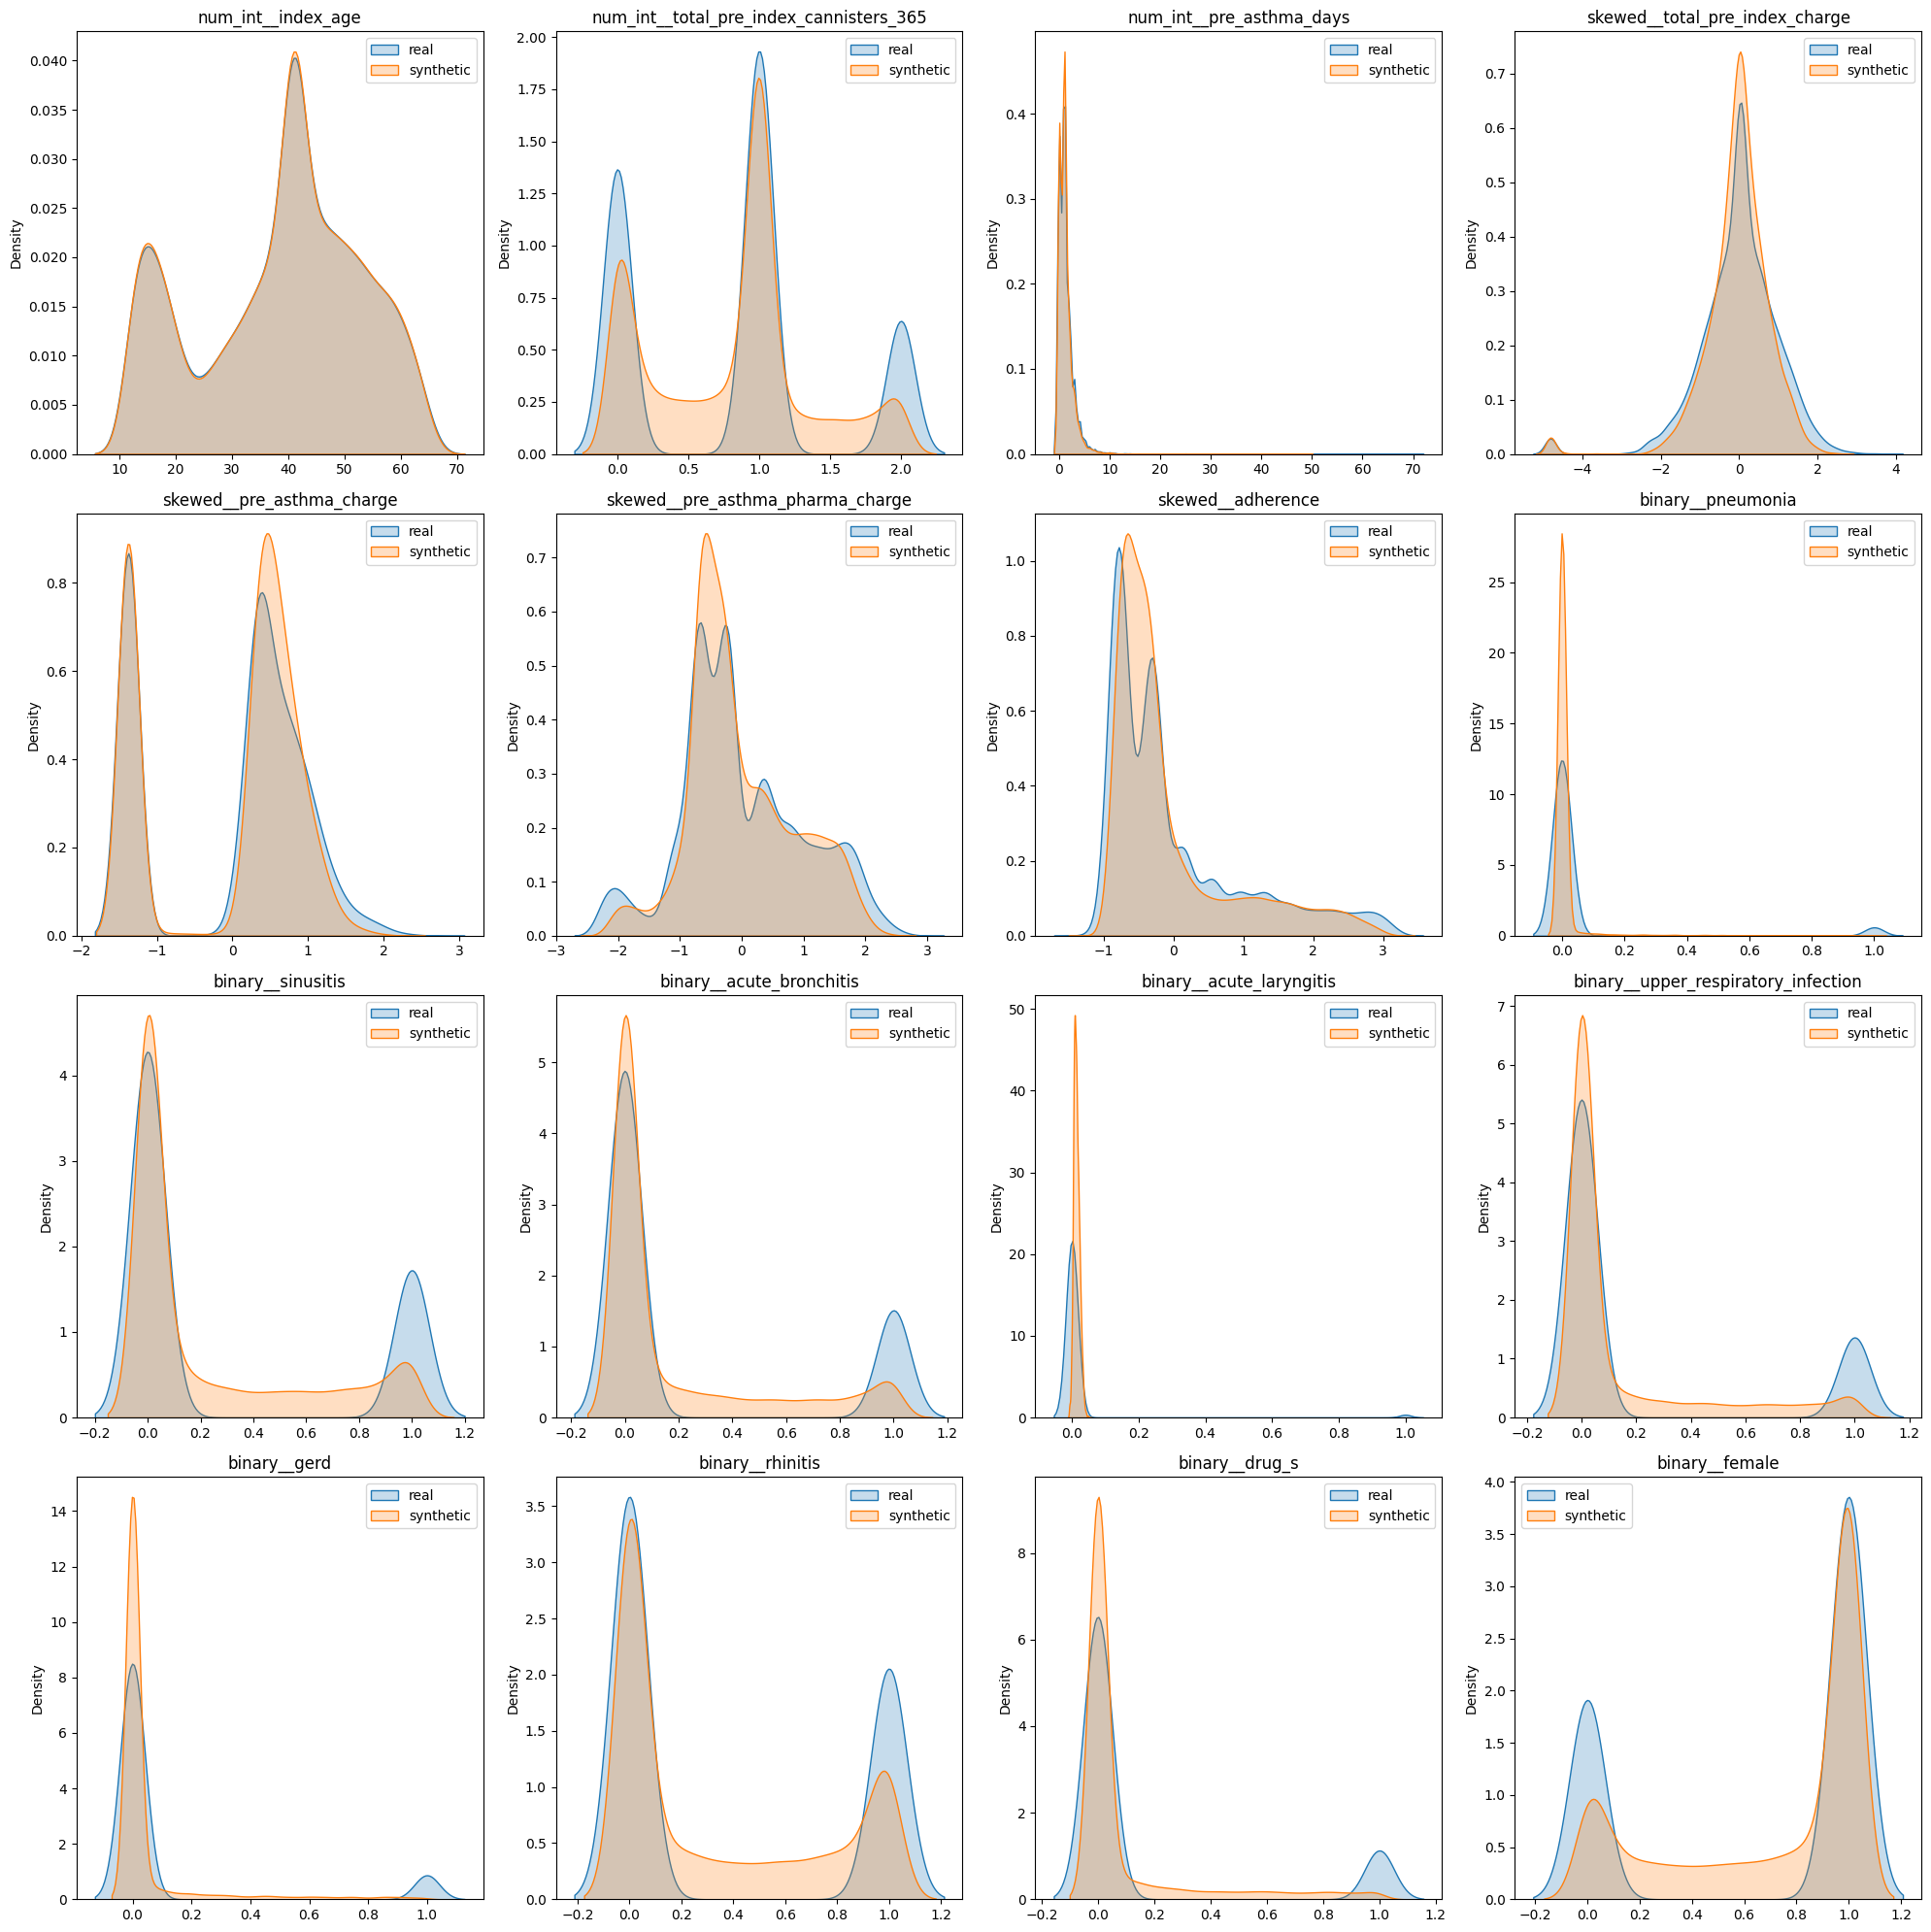

In [28]:
cols = real.columns
n = len(cols)

# taille grille
n_cols = 4
n_rows = math.ceil(n / n_cols)

plt.figure(figsize=(20, 5 * n_rows))

for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i + 1)

    sns.kdeplot(real[col], label="real", fill=True)
    sns.kdeplot(synthetic_df[col], label="synthetic", fill=True)

    plt.title(col)
    plt.legend()

plt.tight_layout()
plt.show()

Les distributions des variables numériques sont globalement bien reproduites dans les données synthétiques. En revanche, les variables binaires présentent des différences importantes, indiquant que leur structure n’est pas correctement capturée par le modèle

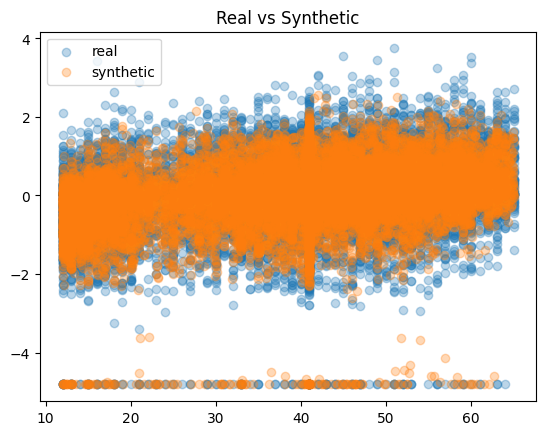

In [29]:
x = "num_int__index_age"
y = "skewed__total_pre_index_charge"

plt.scatter(real[x], real[y], alpha=0.3, label="real")
plt.scatter(synthetic_df[x], synthetic_df[y], alpha=0.3, label="synthetic")

plt.legend()
plt.title("Real vs Synthetic")
plt.show()

Le nuage de points montre que les données synthétiques suivent globalement la même distribution que les données réelles. Cependant, elles apparaissent légèrement plus concentrées, ce qui indique une réduction de la variabilité.

### Les données synthetisé conserve t-elles les corrélation ? 

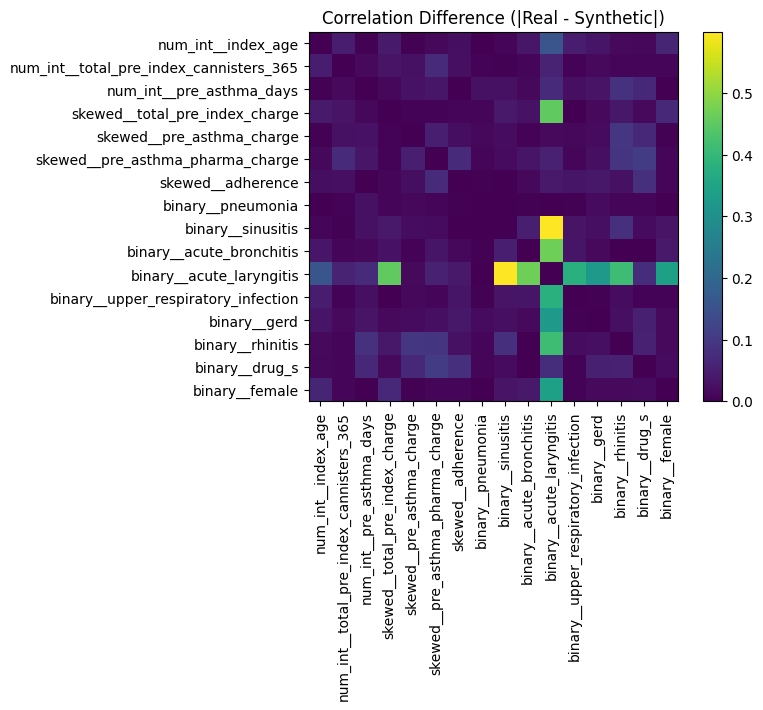

In [30]:
# matrices de corrélation
# foncé = corrélation similaire, clair = corrélation différente
real_corr = np.corrcoef(real.to_numpy(), rowvar=False)
synth_corr = np.corrcoef(synthetic_df.to_numpy(), rowvar=False)
diff_corr = np.abs(real_corr - synth_corr)

plt.figure()
plt.imshow(diff_corr)
plt.title("Correlation Difference (|Real - Synthetic|)")
plt.colorbar()
plt.xticks(range(len(real.columns)), real.columns, rotation=90)
plt.yticks(range(len(real.columns)), real.columns)
plt.show()

La plus part des relations sont bien gardées , mais les relations entre certains variables (sinusitis, bronchitis , laryngitis , infections ) sont mal reproduites. 

### Est ce que les donnée original se trouve dans les données synthétisé ? Privacy 

In [31]:
def exact_match(real, synth):
    real_set = set(map(tuple, real.to_numpy()))
    synth_set = set(map(tuple, synth.to_numpy()))

    matches = real_set.intersection(synth_set)

    return len(matches)

n_matches = exact_match(real, synthetic_df)
print("Exact matches:", n_matches)

Exact matches: 0


Aucune duplication observé . Y a t il un risque de réidentification ?

In [32]:
# distances synth vs real
dist = pairwise_distances(synthetic_df, real)

# distance minimale pour chaque point synthétique
min_dist = dist.min(axis=1)

print("Distance minimale moyenne :", np.mean(min_dist))
print("Distance minimale min :", np.min(min_dist))

Distance minimale moyenne : 0.6284189529362364
Distance minimale min : 0.003566788606797417


La distances minimale montre que les observations synthétiques sont globalement éloignées des données réelles (distance minimale moyenne ≈ 0.63), donc risque de réidentification tres faible. la distance minimale observée (≈ 0.0035) révèle que certaines observations synthétiques sont très proches de données réelles, suggérant un risque local de similarité élevée.

### Conclusion 

Le modèle reproduit bien les distributions (écart moyen ≈ 3.6%) et les relations entre variables (corr ≈ 0.047). Les données synthétiques sont globalement proches des données réelles tout en restant suffisamment éloignées (DCR ≈ 0.63), garantissant la confidentialité. Quelques similarités locales subsistent, mais le compromis entre réalisme et sécurité est globalement satisfaisant.

***Le modèle génère des données réalistes sans copier les données originales, avec un bon équilibre entre qualité et confidentialité***